# DTs

## Feature eng

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import nucml.datasets as nuc_data


In [3]:

# ==========================================
# 1. LOAD & MERGE DATA
# ==========================================
print(">>> Step 1: Loading Physics & Reaction Data...")

# A. Load EXFOR (Reaction Data) with AME physics attached
exfor_df = nuc_data.load_exfor()

# Standardize MT code for Fission (MT=18)
exfor_df['MT'] = pd.to_numeric(exfor_df['MT'], errors='coerce')
exfor_nf = exfor_df[exfor_df['MT'] == 18]

# Filter for Actinides (Z >= 89)
exfor_nf['Z'] = pd.to_numeric(exfor_nf['Z'], errors='coerce')
actinides_df = exfor_nf[exfor_nf['Z'] >= 89].copy()

# B. Load ENSDF/RIPL (Structure Data: Level Densities, Barriers)
print(">>> Loading RIPL Structure Data...")
ensdf_ml, _, _, _, _, _, _ = nuc_data.load_ensdf_ml(
    cutoff=False, append_ame=True, basic=1, num=True
)

# Prepare RIPL data for merging (Group by Z, A to get average properties per isotope)
ripl_grouped = ensdf_ml.groupby(['Z', 'A']).mean().reset_index()

# C. Merge EXFOR with RIPL
# Note: 'left' merge keeps all EXFOR events, adds structure info where available
master_df = pd.merge(actinides_df, ripl_grouped, on=['Z', 'A'], how='left', suffixes=('_exfor', '_ripl'))

INFO:root: MODE: neutrons
INFO:root: LOW ENERGY: False
INFO:root: LOG: False
INFO:root: BASIC: -1
INFO:root:Reading data from /Users/glsw/main/NucMLClone2/EXFOR/CSV_Files/EXFOR_neutrons/EXFOR_neutrons_MF3_AME_no_RawNaN.csv


>>> Step 1: Loading Physics & Reaction Data...


INFO:root:Data read into dataframe with shape: (4395295, 104)
INFO:root:Finished. Resulting dataset has shape (4395295, 104)
INFO:root:AME: Reading and loading Atomic Mass Evaluation files from: 
 /Users/glsw/main/NucMLClone2/AME/CSV_Files/AME_all_merged_no_NaN.csv
INFO:root:Dropping unnecessary features and one-hot encoding categorical columns...
INFO:root:Splitting dataset into training and testing...
INFO:root:Normalizing dataset...
INFO:root:Fitting new scaler.
INFO:root:Finished. Resulting dataset has shape (72667, 12), Training and Testing dataset shapes are (50866, 11) and (21801, 11) respesctively.


>>> Loading RIPL Structure Data...


In [4]:


# ==========================================
# 2. THE CRITICAL FILTER: FAST REGIME ONLY
# ==========================================
print(">>> Step 2: Applying Fast Regime Filter...")

# Identify the Energy Column (fixes the renaming issue)
energy_col = 'Energy_exfor' if 'Energy_exfor' in master_df.columns else 'Energy'

# !!! CRITICAL FILTER !!!
# We remove everything below 200 keV (200,000 eV).
# This removes the resonance region and focuses on the threshold rise.
fast_regime_df = master_df[master_df[energy_col] >= 200000].copy()

print(f"Original Data Points: {len(actinides_df)}")
print(f"Fast Regime Points (>200 keV): {len(fast_regime_df)}")

>>> Step 2: Applying Fast Regime Filter...
Original Data Points: 536771
Fast Regime Points (>200 keV): 34255


In [5]:
# ==========================================
# 3. FEATURE ENGINEERING & CLEANING (Fixed)
# ==========================================
print(">>> Step 3: Preparing Training Features...")

# Define the "Ideal" Feature List
desired_features = [
    energy_col,             # Kinematics: Incident Energy
    'Z',                    # Proton Number
    'A',                    # Mass Number
    'Binding_Energy_exfor', # AME: Stability
    'S(n)_exfor',           # AME: Neutron Separation Energy
    'Level_Number',         # RIPL: Proxy for Level Density
    'Num_Decay_Modes',      # RIPL: Decay Complexity
    'Gammas'                # RIPL: De-excitation pathways
]

# Dynamically keep ONLY features that actually exist in the dataframe
features = [feat for feat in desired_features if feat in fast_regime_df.columns]
print(f"Features successfully found and selected: {features}")

target = 'Data' # Cross Section

# Select features and Drop NaNs
df_model = fast_regime_df[features + [target, 'Isotope']].copy()
df_model = df_model.dropna()
# ==========================================
# 4. LOG TRANSFORM (Physics Scaling)
# ==========================================
# Cross sections vary by orders of magnitude. We train on Log10(Data).
df_model['Log_Target'] = np.log10(df_model[target] + 1e-10)


>>> Step 3: Preparing Training Features...
Features successfully found and selected: ['Energy_exfor', 'Z', 'A', 'Binding_Energy_exfor', 'S(n)_exfor', 'Level_Number']


In [6]:


# ==========================================
# 5. LEAVE-ONE-OUT SPLIT (Am-241)
# ==========================================
target_isotope = '241Am'

train_df = df_model[df_model['Isotope'] != target_isotope]
test_df  = df_model[df_model['Isotope'] == target_isotope]

X_train = train_df[features]
y_train_log = train_df['Log_Target']

X_test = test_df[features]
y_test_log = test_df['Log_Target']

print(f"Training on {len(train_df)} points (U, Pu, Th...)")
print(f"Testing on {len(test_df)} points (Am-241 Only)")


Training on 33682 points (U, Pu, Th...)
Testing on 573 points (Am-241 Only)


In [7]:

# ==========================================
# 6. MODEL TRAINING (XGBoost)
# ==========================================
print(">>> Step 4: Training Physics Model...")

model = XGBRegressor(
    n_estimators=500,       # More trees for smoother curves
    max_depth=10,           # Depth to capture threshold curvature
    learning_rate=0.05,     # Slower learning for better generalization
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train_log)


>>> Step 4: Training Physics Model...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


>>> Step 5: Visualizing Results...


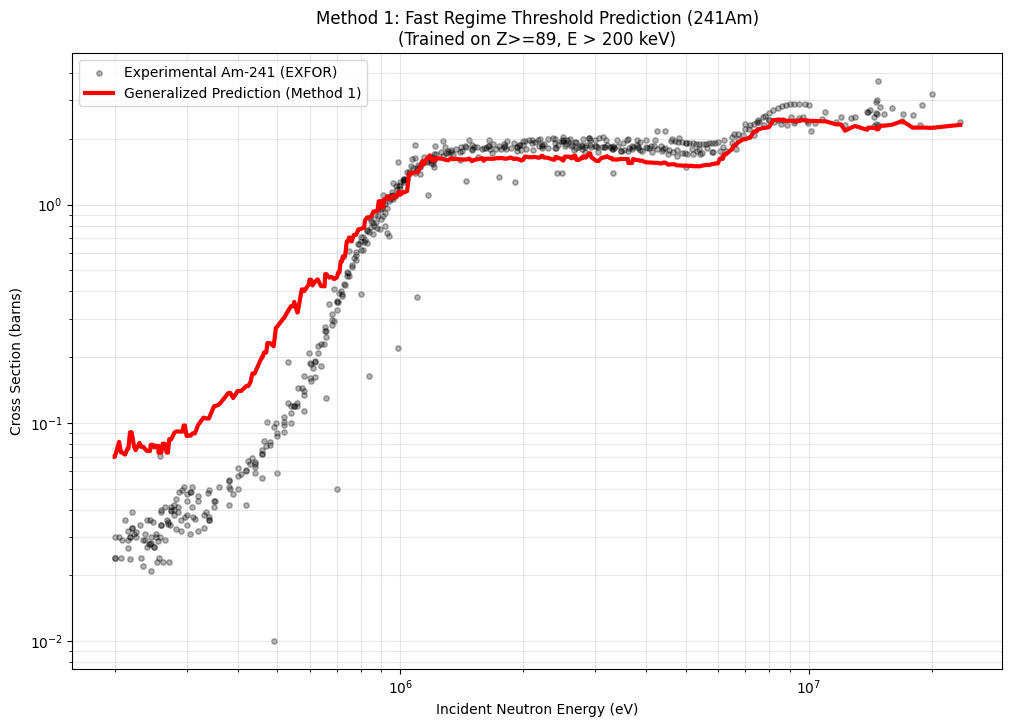

Log-Space MSE: 0.0609


In [8]:

# ==========================================
# 7. PREDICTION & VISUALIZATION
# ==========================================
print(">>> Step 5: Visualizing Results...")

# Predict
y_pred_log = model.predict(X_test)
y_pred_real = 10**y_pred_log # Inverse Transform

# Sort for plotting
sort_idx = np.argsort(X_test[energy_col].values)
E_plot = X_test[energy_col].values[sort_idx]
y_pred_plot = y_pred_real[sort_idx]
y_actual_plot = (10**y_test_log.values)[sort_idx] # Convert actuals back for plot

# Plot
plt.figure(figsize=(12, 8))

# Experimental Data
plt.scatter(E_plot, y_actual_plot, color='black', s=15, alpha=0.3, label='Experimental Am-241 (EXFOR)')

# Model Prediction
plt.plot(E_plot, y_pred_plot, color='red', linewidth=3, label='Generalized Prediction (Method 1)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Incident Neutron Energy (eV)')
plt.ylabel('Cross Section (barns)')
plt.title(f'Method 1: Fast Regime Threshold Prediction ({target_isotope})\n(Trained on Z>=89, E > 200 keV)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# Metrics
mse_log = mean_squared_error(y_test_log, y_pred_log)
print(f"Log-Space MSE: {mse_log:.4f}")

In [14]:
import os
path = "/Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/"
if os.path.exists(path):
    print(f"Contents of {path}:")
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f"{subindent}{f}")
else:
    print("Base directory for Am241 evaluations not found!")

Contents of /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/:
/
jeff3.3/
    tables/
        xs/
            n-Am241-MT002.jeff3.3
            n-Am241-MT002-G069.jeff3.3
            n-Am241-MT060.jeff3.3
            n-Am241-MT070.jeff3.3
            n-Am241-MT084.jeff3.3
            n-Am241-MT079.jeff3.3
            n-Am241-MT069.jeff3.3
            n-Am241-MT205.jeff3.3
            n-Am241-MT056.jeff3.3
            n-Am241-MT002-G700.jeff3.3
            n-Am241-MT024.jeff3.3
            n-Am241-MT068.jeff3.3
            n-Am241-MT078.jeff3.3
            n-Am241-MT102-G700.jeff3.3
            n-Am241-MT204.jeff3.3
            n-Am241-MT057.jeff3.3
            n-Am241-MT025.jeff3.3
            n-Am241-MT003.jeff3.3
            n-Am241-MT071.jeff3.3
            n-Am241-MT061.jeff3.3
            n-Am241-MT085.jeff3.3
            n-Am241-MT102-G069.jeff3.3
            n-Am241-MT206.jeff3.3
            n-Am241-MT018.jeff3.3
            n-Am241-MT102.jeff3.3
            n-Am241-MT

INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/endfb8.0/tables/xs/n-Am241-MT018.endfb8.0
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  evaluation = pd.read_csv(path, skiprows=5, header=None, names=["Energy", "Data", "dDataLow", "dDataUpp"], delim_whitespace=True)
INFO:root:EVALUATION: Converting MeV to eV...
INFO:root:EVALUATION: Converting mb to b...
INFO:root:EVALUATION: Finished. ENDF data contains 16294 datapoints.
INFO:root:EVALUATION: Extracting data from /Users/glsw/main/NucMLClone2/Evaluated_Data/neutrons/Am241/tendl.2019/tables/xs/n-Am241-MT018.tendl.2019
/opt/anaconda3/envs/ml_msci_v2/lib/python3.10/site-packages/nucml/datasets.py:149: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future ver

>>> Step 5: Visualizing Results with Multiple Benchmarks...


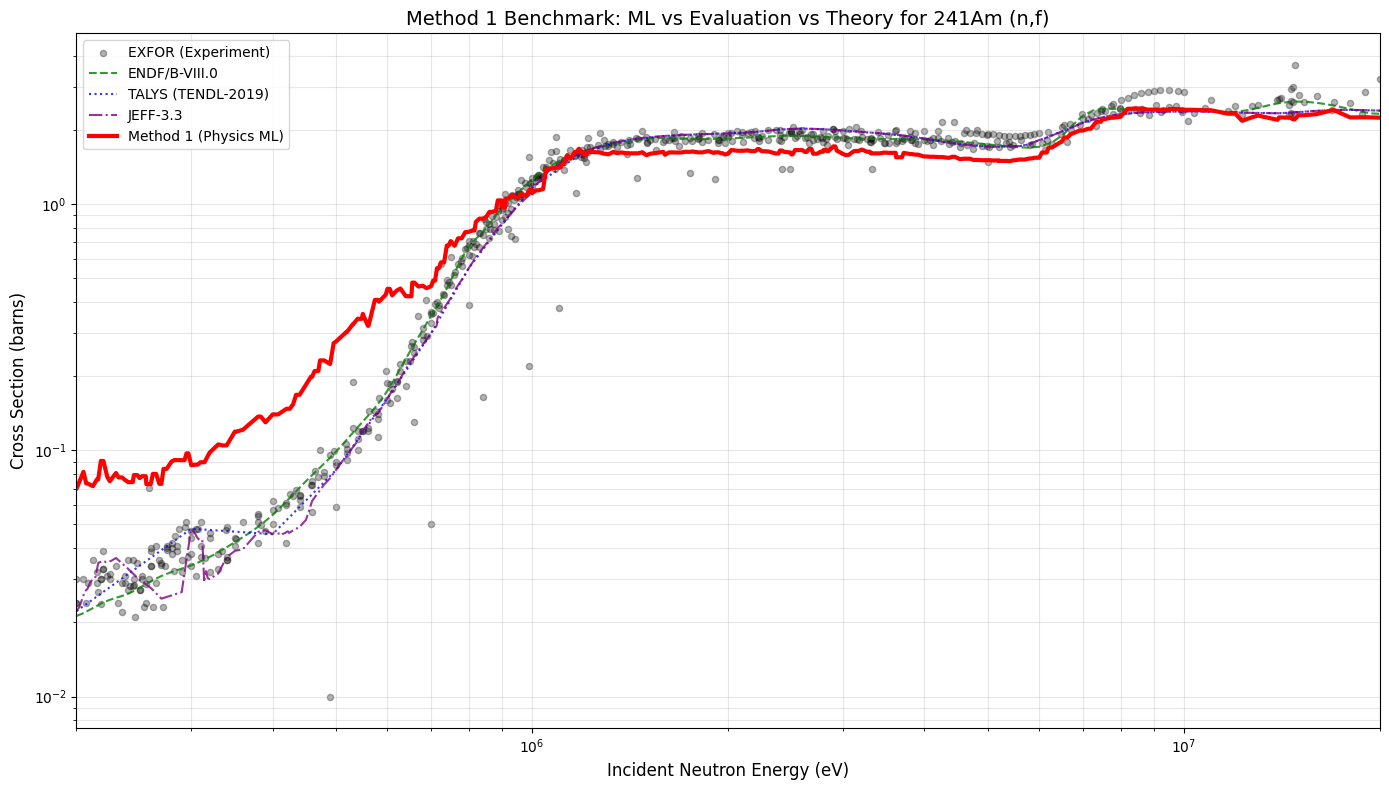

In [15]:
# ==========================================
# 7. PREDICTION & VISUALIZATION (FINAL)
# ==========================================
print(">>> Step 5: Visualizing Results with Multiple Benchmarks...")

# 1. Get ML Model Predictions
y_pred_real = 10**model.predict(X_test)
sort_idx = np.argsort(X_test[energy_col].values)
E_plot = X_test[energy_col].values[sort_idx]
y_pred_plot = y_pred_real[sort_idx]
y_actual_plot = (10**y_test_log.values)[sort_idx]

# 2. Setup Plot
plt.figure(figsize=(14, 8))

# 3. Plot EXFOR (Experiment)
plt.scatter(E_plot, y_actual_plot, color='black', s=20, alpha=0.3, label='EXFOR (Experiment)')

# --- HELPER FUNCTION FOR LOADING ---
def load_and_fix(iso, mt, lib, color, style, label):
    try:
        df = nuc_data.load_evaluation(iso, mt, library=lib)
        if not df.empty:
            e = 10**df['Energy'] if df['Energy'].max() < 100 else df['Energy']
            d = 10**df['Data'] if df['Data'].max() < 10 else df['Data']
            # Filter for fast regime
            mask = e >= 2e5
            plt.plot(e[mask], d[mask], color=color, linestyle=style, linewidth=1.5, label=label, alpha=0.8)
            return True
    except:
        return False
    return False

# 4. Plot Benchmarks using your actual directory names
load_and_fix("am241", 18, "endfb8.0", "green", "--", "ENDF/B-VIII.0")
load_and_fix("am241", 18, "tendl.2019", "blue", ":", "TALYS (TENDL-2019)")
load_and_fix("am241", 18, "jeff3.3", "purple", "-.", "JEFF-3.3")

# 5. Plot Your ML Model
plt.plot(E_plot, y_pred_plot, color='red', linewidth=3, label='Method 1 (Physics ML)')

# 6. Final Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlim(2e5, 2e7)
plt.xlabel('Incident Neutron Energy (eV)', fontsize=12)
plt.ylabel('Cross Section (barns)', fontsize=12)
plt.title(f'Method 1 Benchmark: ML vs Evaluation vs Theory for {target_isotope} (n,f)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


 STANDALONE XGBOOST PERFORMANCE: 241Am
Log-Space MSE:  0.0609  (Lower is better)
Log-Space MAE:  0.1690  (Lower is better)
Log-Space R²:   0.8780  (1.0 is perfect)
------------------------------------------
Physical MAE:   0.1861 barns



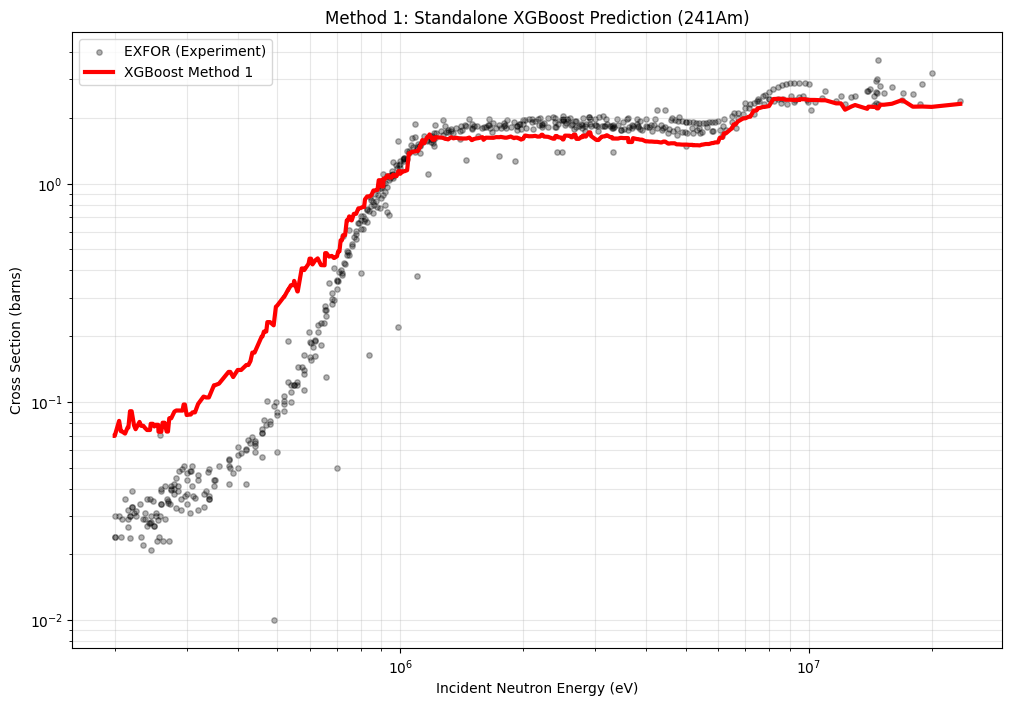

In [16]:
# ==========================================
# 7. PREDICTION, VISUALIZATION & METRICS
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Prediction & Inverse Transform
y_pred_log = model.predict(X_test)
y_pred_real = 10**y_pred_log 

# 2. Preparation for Metrics
y_test_log = y_test_log # Assuming this is already Log10(Data)
y_test_real = 10**y_test_log

# 3. Calculate Scores
# Log-Space (Order of magnitude accuracy)
mse_log = mean_squared_error(y_test_log, y_pred_log)
mae_log = mean_absolute_error(y_test_log, y_pred_log)
r2_log = r2_score(y_test_log, y_pred_log)

# Linear-Space (Physical Barn accuracy)
mae_barns = mean_absolute_error(y_test_real, y_pred_real)

# 4. Print Score Report
print(f"\n==========================================")
print(f" STANDALONE XGBOOST PERFORMANCE: {target_isotope}")
print(f"==========================================")
print(f"Log-Space MSE:  {mse_log:.4f}  (Lower is better)")
print(f"Log-Space MAE:  {mae_log:.4f}  (Lower is better)")
print(f"Log-Space R²:   {r2_log:.4f}  (1.0 is perfect)")
print(f"------------------------------------------")
print(f"Physical MAE:   {mae_barns:.4f} barns")
print(f"==========================================\n")

# 5. Visualization (Existing Plotting Logic)
plt.figure(figsize=(12, 8))
sort_idx = np.argsort(X_test[energy_col].values)
plt.scatter(X_test[energy_col], y_test_real, color='black', s=15, alpha=0.3, label='EXFOR (Experiment)')
plt.plot(X_test[energy_col].values[sort_idx], y_pred_real[sort_idx], color='red', linewidth=3, label='XGBoost Method 1')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Incident Neutron Energy (eV)')
plt.ylabel('Cross Section (barns)')
plt.title(f'Method 1: Standalone XGBoost Prediction ({target_isotope})')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

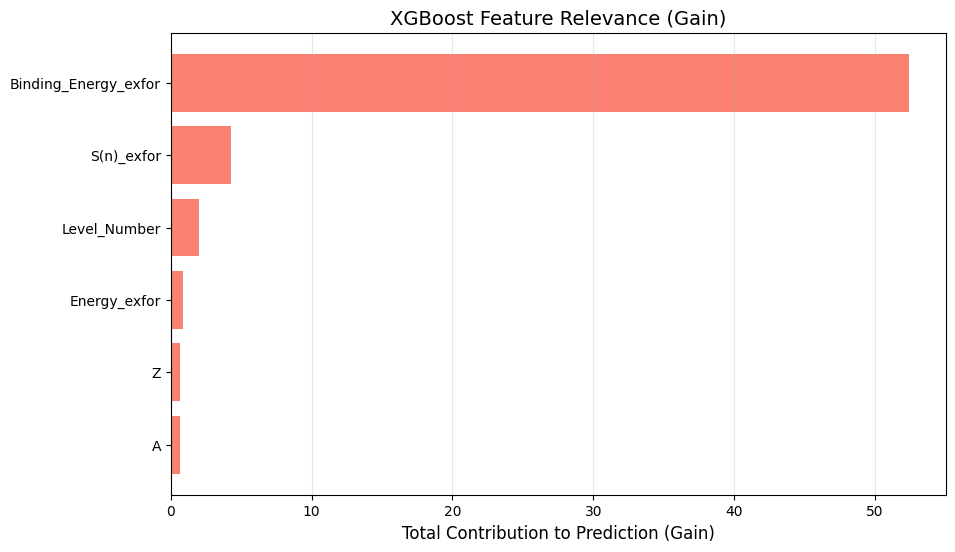

In [17]:
# ==========================================
# 8. XGBOOST FEATURE RELEVANCE
# ==========================================
import xgboost as xgb

# Get importance dictionary from the model
# 'gain' is usually the most physically relevant metric
importance_type = 'gain' 
scores = model.get_booster().get_score(importance_type=importance_type)

# Convert to DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': list(scores.keys()),
    'Importance': list(scores.values())
}).sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='salmon')
plt.title(f'XGBoost Feature Relevance ({importance_type.capitalize()})', fontsize=14)
plt.xlabel('Total Contribution to Prediction (Gain)', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

# EXTRA